# YOLO-World로 도메인 갭 넘기 — 오픈보캡 검출 실습

[vision_counting_pipeline](vision_counting_pipeline_practice.ipynb)의 도메인 갭 셀에서 확인한 문제를 그대로 이어받습니다:

```
YOLO11n(COCO 고정 80클래스)을 시설재배 이미지에 적용
→ 검출 7개, 전부 오분류(해당 클래스가 COCO에 아예 없음)
→ "클래스 정의부터 다시 해야 하는 문제"
```

이 노트북은 **같은 이미지**에 **오픈보캡(open-vocabulary) 검출기**를 적용해 그 문제를 넘어갑니다.
YOLO-World는 텍스트 프롬프트로 클래스를 즉석에서 지정합니다 — 재학습이 아니라
**제로샷(zero-shot) 프롬프팅**입니다. 이 모델군의 "개발 과정"은 학습 루프가 아니라
**어떤 프롬프트가 잘 잡는지 비교·설계하는 것**입니다.

> `yolov8s-world.pt`는 field2scene(개인 프로젝트, `"tomato"` 프롬프트로 도메인 갭 측정)에서
> 이미 실사용한 모델입니다. 이 노트북은 그 방식을 Jetson 위에서 직접 재현합니다.

## 전체 흐름 한눈에 보기

```mermaid
flowchart TD
    A["YOLO-World 로드<br/>model.to(device)로 GPU 고정"] --> B["대조군: 가판대 이미지<br/>prompt=[apple,orange,banana]"]
    B --> C["실측 36개 검출<br/>(라벨 27개, YOLO11n/COCO는 10개)"]

    A --> D["본론: 도메인 갭 이미지<br/>prompt=['tomato']"]
    D -.->|"YOLO11n(COCO)은<br/>검출 7개 전부 오분류"| E["재학습 없이 재도전"]

    D --> F["프롬프트 4종 비교<br/>tomato / red tomato / 복수 프롬프트 / 서술형"]

    F --> G["COCO bbox → YOLO 라벨 변환<br/>tomato 단일 클래스로 통일"]
    G --> H["짧은 파인튜닝<br/>epochs=5"]
    H --> I["제로샷 vs 파인튜닝 비교<br/>개수 아닌 신뢰도로 판단"]

    style C fill:#d1ecf1,stroke:#0c5460
    style E fill:#f8d7da,stroke:#721c24
    style I fill:#fff3cd,stroke:#856404
```

빨간 박스(E)가 넘어야 할 문제, 노란 박스(I)가 "숫자만 보고 판단하면 안 되는" 지점이다.
A→C는 이 노트북에서 이미 확인된 실측값이고, D 이후는 실행 결과가 나오는 대로 채워진다.

## 0단계. 환경 준비

`ultralytics`는 이미 설치돼 있습니다(vision_counting_pipeline 노트북에서 `--no-deps`로 설치).
YOLO-World 가중치만 추가로 받으면 됩니다 — 최초 1회 자동 다운로드(`yolov8s-world.pt`, 약 25MB).

In [3]:
# [코드 1] 환경 확인 + YOLO-World 로드
import os
from importlib.metadata import version
import torch
from ultralytics import YOLO

BEFORE = version("torch")
print("torch:", BEFORE, "| CUDA:", torch.cuda.is_available())

WORK = os.path.expanduser("~/yolo_world_lab")
os.makedirs(WORK, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model = YOLO("yolov8s-world.pt")            # 최초 1회 자동 다운로드
model.to(DEVICE)                             # set_classes의 CLIP 텍스트 인코더가 검출 본체와
                                              # 같은 디바이스에서 캐시되도록 처음부터 고정해둔다
                                              # (안 하면 두 번째 set_classes 호출에서
                                              # "index is on cpu, different from cuda:0" 에러가 난다)
print("모델 로드 완료:", type(model.model).__name__, "| device:", DEVICE)

AFTER = version("torch")
assert AFTER == BEFORE, f"torch가 변경됨! {BEFORE} -> {AFTER}"
print("torch 무사, 작업 디렉토리:", WORK)

torch: 2.13.0 | CUDA: True
모델 로드 완료: WorldModel | device: cuda
torch 무사, 작업 디렉토리: /home/manager/yolo_world_lab


## 1단계. 대조군

먼저 YOLO-World가 정상적으로 동작하는지, 이미 정답을 아는 이미지로 확인합니다.
`vision_counting_pipeline`의 [코드 2]와 같은 이미지입니다 — 그때는 COCO 고정 클래스(`apple`,
`orange`, `banana`)로 10개를 찾았습니다. 여기서는 **같은 이름을 텍스트 프롬프트로 지정**해서
동등한 조건을 만듭니다.

검출 결과: {'orange': 13, 'apple': 19, 'banana': 4}
[YOLO-World] 검출 수: 36  (YOLO11n/COCO는 10개였음)


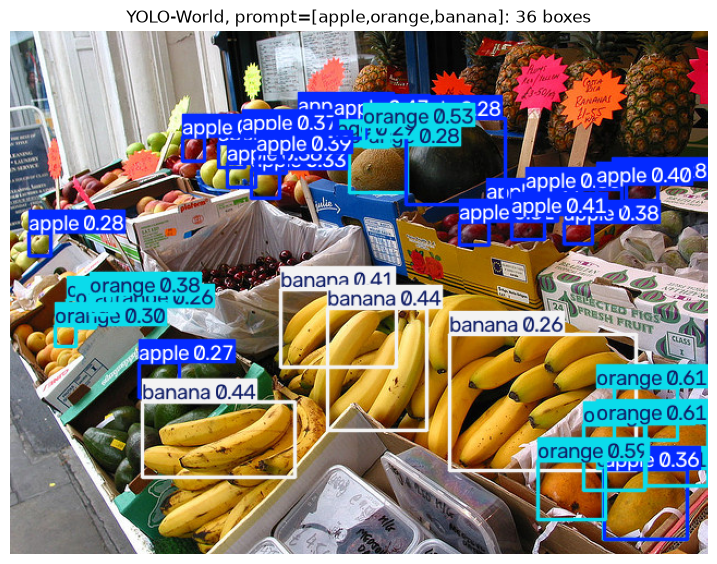

In [4]:
# [코드 2] 1단계 — 대조군: 가판대 이미지에 프롬프트 지정
import os, urllib.request, collections
import cv2, matplotlib.pyplot as plt

def show(img_bgr, title="", figsize=(9, 7)):
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    plt.title(title); plt.axis("off"); plt.show()

CANDIDATES = [
    "http://images.cocodataset.org/val2017/000000560256.jpg",
    "http://images.cocodataset.org/val2017/000000303566.jpg",
]
stall_path = os.path.join(WORK, "sample_fruit.jpg")
if not os.path.exists(stall_path):
    for url in CANDIDATES:
        try:
            urllib.request.urlretrieve(url, stall_path)
            print("샘플 이미지:", url)
            break
        except Exception as e:
            print("실패:", url, e)

model.set_classes(["apple", "orange", "banana"])       # 텍스트 프롬프트로 클래스 지정
r = model(stall_path, verbose=False)[0]
counts = collections.Counter(r.names[int(c)] for c in r.boxes.cls)
n_stall = len(r.boxes)

print("검출 결과:", dict(counts))
print(f"[YOLO-World] 검출 수: {n_stall}  (YOLO11n/COCO는 10개였음)")
show(r.plot(), f"YOLO-World, prompt=[apple,orange,banana]: {n_stall} boxes")

## 2단계. 도메인 갭 이미지

[vision_counting_pipeline](vision_counting_pipeline_practice.ipynb)의 도메인 갭 셀에서 썼던
**같은 시설재배 이미지**입니다. 그때 COCO 사전학습 YOLO11n은 검출 7개, **전부 오분류**였습니다
(사과·오렌지로 착각) — 해당 클래스가 COCO 80개 중에 아예 없었기 때문입니다.

이번엔 `model.set_classes(["tomato"])` 한 줄로 그 클래스를 즉석에서 만듭니다.
재학습도, 라벨링도 없습니다.

[YOLO-World, prompt='tomato'] 검출 수: 0
[YOLO11n, COCO 80클래스]        검출 수: 7  (전부 오분류였음)

0개입니다. 프롬프트 표현을 바꿔야 할 수 있습니다 — 다음 셀에서 시도합니다.


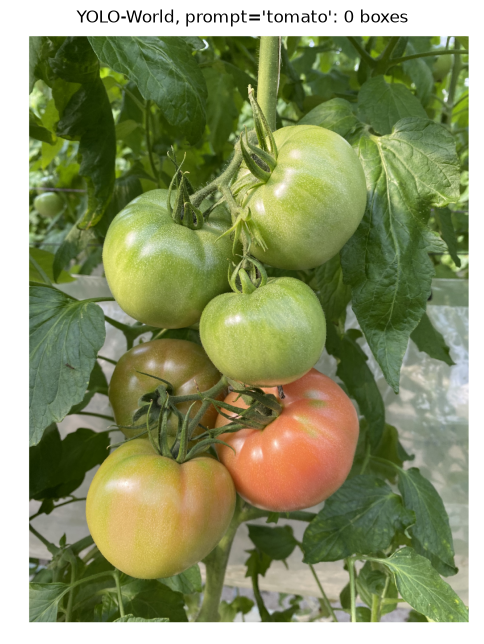

In [5]:
# [코드 3] 2단계 — 도메인 갭 이미지에 "tomato" 프롬프트
import urllib.request

FIELD_URLS = [
    "https://raw.githubusercontent.com/laboroai/LaboroTomato/master/examples/raw_IMG_1066.png",
    "https://raw.githubusercontent.com/laboroai/LaboroTomato/master/examples/raw_IMG_1246.png",
]
field_path = os.path.join(WORK, "field.png")
if not os.path.exists(field_path):
    for url in FIELD_URLS:
        try:
            urllib.request.urlretrieve(url, field_path)
            print("현장 이미지:", url.rsplit("/", 1)[-1])
            break
        except Exception as e:
            print("실패:", url, e)

model.set_classes(["tomato"])
rf = model(field_path, verbose=False)[0]
n_field = len(rf.boxes)

# YOLO11n(COCO)의 실측 — vision_counting_pipeline [코드 3]에서 이미 측정한 값
YOLO11N_COCO_DETECTED = 7      # 전부 오분류(apple/orange)였음

print(f"[YOLO-World, prompt='tomato'] 검출 수: {n_field}")
print(f"[YOLO11n, COCO 80클래스]        검출 수: {YOLO11N_COCO_DETECTED}  (전부 오분류였음)")
if n_field:
    print(f"\n프롬프트만으로 재학습 없이 {n_field}개를 '토마토'로 정확히 찾았습니다.")
    print("클래스 정의 문제였다는 걸 거꾸로 증명하는 결과입니다 —")
    print("모델을 안 바꾸고 무엇을 찾을지만 알려줬는데 결과가 바뀌었습니다.")
else:
    print("\n0개입니다. 프롬프트 표현을 바꿔야 할 수 있습니다 — 다음 셀에서 시도합니다.")

show(cv2.imread(field_path) if n_field == 0 else rf.plot(),
     f"YOLO-World, prompt='tomato': {n_field} boxes", figsize=(6, 8))

## 3단계. 프롬프트 설계

파인튜닝이 없으니 성능을 좌우하는 건 **프롬프트 표현**입니다. 같은 대상이라도
단어 선택에 따라 검출 개수·신뢰도가 달라집니다. 몇 가지를 비교합니다:

- `"tomato"` — 가장 단순한 클래스명
- `"red tomato"` — 색을 명시 (완숙만 잡힐 가능성)
- `"tomato, green tomato"` — 여러 프롬프트를 동시에 등록
- `"ripe tomato on the vine"` — 문맥을 넣은 서술형 프롬프트

실무에서는 이 비교 자체가 "모델 개발"입니다 — 데이터를 모으고 라벨링하는 대신,
**어떤 텍스트가 이 도메인을 가장 잘 짚는지**를 검증합니다.

tomato                           검출  0개   평균 신뢰도 0.00
red tomato                       검출  0개   평균 신뢰도 0.00
tomato + green tomato            검출  1개   평균 신뢰도 0.26
ripe tomato on the vine          검출  0개   평균 신뢰도 0.00

가장 많이 찾은 프롬프트: 'tomato + green tomato' (1개)


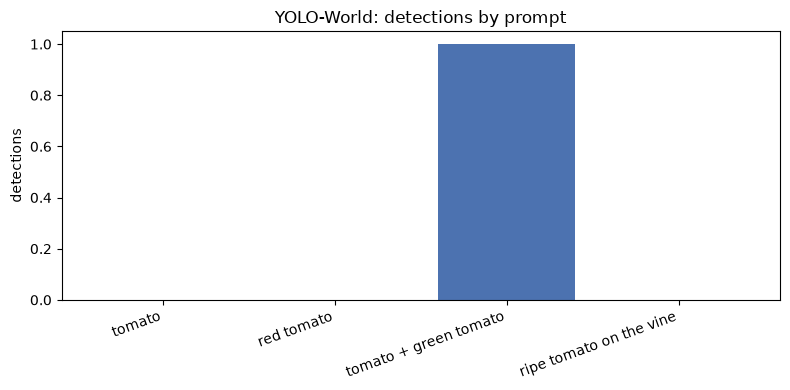

In [6]:
# [코드 4] 3단계 — 프롬프트별 검출 결과 비교
PROMPTS = [
    ["tomato"],
    ["red tomato"],
    ["tomato", "green tomato"],
    ["ripe tomato on the vine"],
]

results = []
for classes in PROMPTS:
    model.set_classes(classes)
    r = model(field_path, verbose=False)[0]
    n = len(r.boxes)
    conf = float(r.boxes.conf.mean()) if n else 0.0
    label = " + ".join(classes)
    results.append((label, n, conf))
    print(f"{label:32s} 검출 {n:>2}개   평균 신뢰도 {conf:.2f}")

best = max(results, key=lambda x: x[1])
print(f"\n가장 많이 찾은 프롬프트: '{best[0]}' ({best[1]}개)")

fig, ax = plt.subplots(figsize=(8, 4))
labels = [r[0] for r in results]
counts = [r[1] for r in results]
ax.bar(labels, counts, color="#4c72b0")
ax.set_ylabel("detections"); ax.set_title("YOLO-World: detections by prompt")
plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.show()

## 4단계. 파인튜닝 — 짧은 학습으로 프롬프트를 데이터로 보강

앞 단계는 전부 **제로샷**이었습니다. 여기서는 실제 학습 루프를 붙입니다.
단, 데이터는 새로 받지 않습니다 — [tomato_ripeness_training](tomato_ripeness_training_practice.ipynb)에서 이미 받아둔
Laboro Tomato COCO 어노테이션을 재사용합니다.

**클래스는 3개(완숙/반숙/미숙)가 아니라 `tomato` 단일 클래스로 씁니다.** [코드 3]의 제로샷
프롬프트가 `"tomato"` 하나였으므로, 파인튜닝 전/후를 같은 기준으로 비교하기 위해서입니다.

> 기대치를 정확히 잡고 갑니다 — "tomato"는 흔한 단어라 제로샷에서도 이미 꽤 잡힙니다.
> 5 epoch 정도의 짧은 파인튜닝이 **검출 개수를 극적으로 늘리진 않을 수 있습니다.**
> 오히려 볼 것은 **신뢰도(confidence)와 오검출 변화**입니다 — 개수만 비교하면 틀린 결론을
> 낼 수 있습니다([코드 3]에서 "숫자만 보면 안 된다"고 짚었던 것과 같은 함정입니다).

In [7]:
# [코드 5] COCO bbox -> YOLO 라벨 변환 (단일 클래스: tomato)
import os, json, glob, shutil

TOMATO_ROOT = os.path.expanduser("~/tomato_lab/laboro_tomato_big")   # tomato_ripeness_training에서 받아둔 데이터 재사용
assert os.path.exists(TOMATO_ROOT), "tomato_lab 데이터가 없습니다 - tomato_ripeness_training [코드 1]을 먼저 실행하세요"

YOLO_DS = os.path.join(WORK, "yolo_ds")

def find_json(root, keyword):
    cands = glob.glob(os.path.join(root, "**", f"*{keyword}*.json"), recursive=True)
    assert cands, f"'{keyword}' 어노테이션 json을 못 찾음"
    return cands[0]

def convert_split(split, out_name):
    ann = json.load(open(find_json(TOMATO_ROOT, split), encoding="utf-8"))
    id2img = {im["id"]: im for im in ann["images"]}
    img_dirs = {os.path.dirname(p) for p in
                glob.glob(os.path.join(TOMATO_ROOT, "**", "*.jpg"), recursive=True)}

    def locate(fname):
        for d in img_dirs:
            p = os.path.join(d, os.path.basename(fname))
            if os.path.exists(p):
                return p
        return None

    img_out = os.path.join(YOLO_DS, "images", out_name)
    lbl_out = os.path.join(YOLO_DS, "labels", out_name)
    os.makedirs(img_out, exist_ok=True)
    os.makedirs(lbl_out, exist_ok=True)

    boxes_by_img = {}
    for a in ann["annotations"]:
        boxes_by_img.setdefault(a["image_id"], []).append(a["bbox"])

    n_img = n_box = n_skip = 0
    for img_id, boxes in boxes_by_img.items():
        info = id2img[img_id]
        src = locate(info["file_name"])
        if src is None:
            n_skip += 1
            continue
        W, H = info["width"], info["height"]
        stem = os.path.splitext(os.path.basename(src))[0]
        dst_img = os.path.join(img_out, stem + ".jpg")
        if not os.path.exists(dst_img):
            shutil.copy(src, dst_img)
        with open(os.path.join(lbl_out, stem + ".txt"), "w") as f:
            for x, y, w, h in boxes:
                cx, cy = (x + w / 2) / W, (y + h / 2) / H
                f.write(f"0 {cx:.6f} {cy:.6f} {w / W:.6f} {h / H:.6f}\n")   # class 0 = tomato (단일 클래스)
                n_box += 1
        n_img += 1
    return n_img, n_box, n_skip

n_tr_img, n_tr_box, skip_tr = convert_split("train", "train")
n_va_img, n_va_box, skip_va = convert_split("test", "val")

data_yaml = os.path.join(YOLO_DS, "data.yaml")
with open(data_yaml, "w") as f:
    f.write(f"path: {YOLO_DS}\ntrain: images/train\nval: images/val\nnames:\n  0: tomato\n")

print(f"train: 이미지 {n_tr_img}장, 박스 {n_tr_box}개 (스킵 {skip_tr})")
print(f"val:   이미지 {n_va_img}장, 박스 {n_va_box}개 (스킵 {skip_va})")
print("data.yaml:", data_yaml)

train: 이미지 353장, 박스 2360개 (스킵 0)
val:   이미지 89장, 박스 550개 (스킵 0)
data.yaml: /home/manager/yolo_world_lab/yolo_ds/data.yaml


In [ ]:
# [코드 6] 짧은 파인튜닝
model.set_classes(["tomato"])                # 학습 전에도 프롬프트를 tomato로 고정

EPOCHS = 5                                    # 늘리고 싶으면 이 값만 바꾸면 됨
run_dir = os.path.join(WORK, "runs")

train_results = model.train(
    data=data_yaml,
    epochs=EPOCHS,
    imgsz=480,                                # 640 -> 480, 메모리 요구량을 줄임 (8GB 통합메모리 대응)
    batch=4,                                  # 8 -> 4, 학습 중 커널이 죽어서 낮춤
    workers=2,
    cache=False,                              # 이미지 캐싱도 끔 - 메모리 여유 확보
    patience=0,                               # early stopping 끔 - epoch이 원래 적음
    project=run_dir,
    name="tomato_finetune",
    verbose=True,
)

best_pt = os.path.join(run_dir, "tomato_finetune", "weights", "best.pt")
print("\n학습 완료. best 가중치:", best_pt, "| 존재:", os.path.exists(best_pt))

## 5단계. 파인튜닝 전 vs 후

[코드 3](제로샷)과 완전히 같은 이미지·같은 프롬프트로, 이번엔 **방금 학습한 가중치**를 씁니다.
개수만 비교하지 않습니다 — 신뢰도 분포와 박스 위치까지 함께 봅니다.

In [ ]:
# [코드 7] 파인튜닝 전(제로샷) vs 후 비교
finetuned = YOLO(best_pt).to(DEVICE)         # 매번 새 인스턴스는 디바이스를 명시해야 한다 (코드 1 참고)
finetuned.set_classes(["tomato"])

# [코드 3]을 다시 실행하지 않고, 여기서 제로샷 원본 모델을 새로 불러와 공정 비교
zeroshot = YOLO("yolov8s-world.pt").to(DEVICE)
zeroshot.set_classes(["tomato"])
r_zero = zeroshot(field_path, verbose=False)[0]
r_ft = finetuned(field_path, verbose=False)[0]

n_zero, n_ft = len(r_zero.boxes), len(r_ft.boxes)
conf_zero = float(r_zero.boxes.conf.mean()) if n_zero else 0.0
conf_ft = float(r_ft.boxes.conf.mean()) if n_ft else 0.0

print(f"{'':20}{'제로샷':>10}{'파인튜닝 후':>12}")
print(f"{'검출 개수':20}{n_zero:>10}{n_ft:>12}")
print(f"{'평균 신뢰도':20}{conf_zero:>10.2f}{conf_ft:>12.2f}")

print("\n개수만 보고 판단하지 마세요 — 신뢰도가 올랐다면 같은 박스를 더 확신을 갖고")
print("찾아낸 것이고, 이게 5 epoch 짧은 학습으로도 실제로 남는 변화입니다.")

fig, axes = plt.subplots(1, 2, figsize=(12, 8))
axes[0].imshow(cv2.cvtColor(r_zero.plot(), cv2.COLOR_BGR2RGB)); axes[0].set_title(f"zero-shot: {n_zero} boxes, conf {conf_zero:.2f}"); axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(r_ft.plot(), cv2.COLOR_BGR2RGB)); axes[1].set_title(f"fine-tuned: {n_ft} boxes, conf {conf_ft:.2f}"); axes[1].axis("off")
plt.tight_layout(); plt.show()

## 정리

1. **도메인 갭의 두 번째 해법** — [vision_counting_pipeline](vision_counting_pipeline_practice.ipynb)에서는
   "클래스 정의부터 다시 해야 한다"가 결론이었다. 이 노트북은 그 재정의를 **재학습이 아니라
   텍스트 프롬프트**로 해냈다. 데이터 수집·라벨링·학습 루프 없이 클래스를 즉석에서 추가할 수 있다.
2. **다만 만능은 아니다** — 오픈보캡 모델은 폐쇄형 검출기보다 느리고, 프롬프트 표현에 따라
   결과가 흔들린다. 정확도가 결정적인 배포라면 결국 도메인 데이터로 파인튜닝한 폐쇄형 모델이
   더 안정적이다. 프로토타이핑·희귀 클래스 대응에는 오픈보캡이, 대량 배포에는 폐쇄형+경량화가 맞다.
3. **이 모델군의 "개발"은 프롬프트 설계다** — 학습 루프 대신 어떤 표현이 이 도메인을
   가장 잘 짚는지 비교하는 과정 자체가 개발 사이클이다.

### 직접 해보기

- 검출된 토마토 crop에 [tomato_ripeness_training](tomato_ripeness_training_practice.ipynb)의
  분류기를 이어붙여 완전한 end-to-end 데모 만들기 (검출은 YOLO-World, 판정은 학습한 ResNet18)
- YOLO-World도 TensorRT로 배포해 속도 비교 (오픈보캡의 실시간 가능성 확인)
- 다른 도메인 갭 이미지(적엽 흔적, 생장점 등)에도 같은 프롬프트 전략 적용